In [1]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt

homic package imported


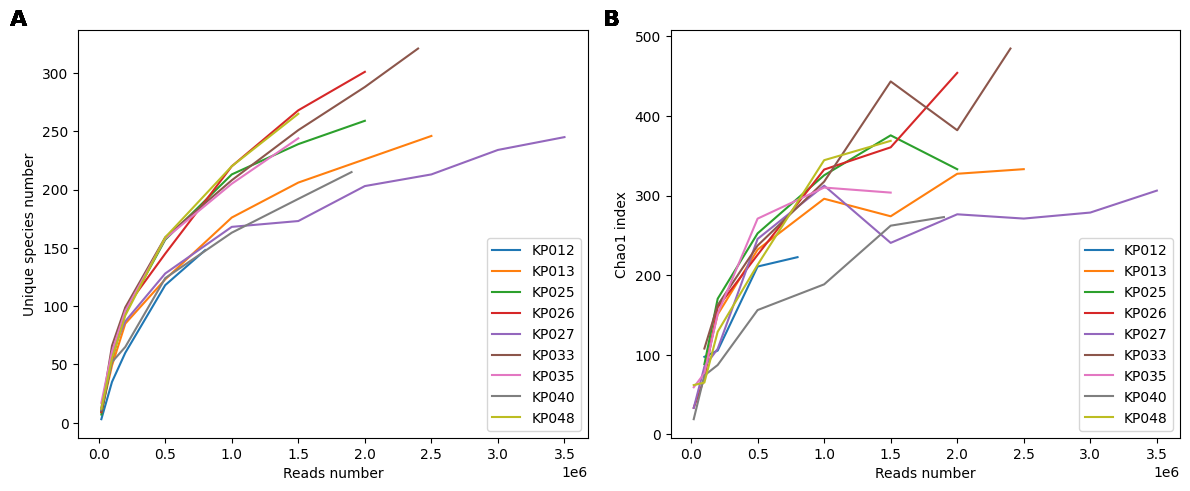

In [2]:
all_samps = np.array(["KP005", "KP012", "KP013", "KP016", "KP024", "KP025", "KP026", "KP027", "KP029",
             "KP033","KP035","KP038","KP040","KP046","KP047","KP048"])

inds = [1,2,5,6,7,9,10,12,15]


# 1: [10000, 50000, 100000, 250000, 400000]
# 2: [10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1250000]
# 5: [10000, 50000, 100000, 250000, 500000, 750000, 1000000]
# 6: [10000, 50000, 100000, 250000, 500000, 750000, 1000000]
# 7: [10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1250000, 1500000, 1750000]
# 9: [10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1200000]
#10: [10000, 50000, 100000, 250000, 500000, 750000]
#12: [10000, 50000, 100000, 250000, 500000, 750000, 950000]
#15: [10000, 50000, 100000, 250000, 500000, 750000]
all_ns = [[10000, 50000, 100000, 250000, 400000],
[10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1250000],
[10000, 50000, 100000, 250000, 500000, 750000, 1000000],
[10000, 50000, 100000, 250000, 500000, 750000, 1000000],
[10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1250000, 1500000, 1750000],
[10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1200000],
[10000, 50000, 100000, 250000, 500000, 750000],
[10000, 50000, 100000, 250000, 500000, 750000, 950000],
[10000, 50000, 100000, 250000, 500000, 750000]]

## 1 - 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, ind in enumerate(inds):
    reads_n = all_ns[i]
    species_num = []
    chao_all = []
    
    for n, samp in enumerate(reads_n):
        
        path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-"+str(ind+1)+"/blastn_nt_500/" + all_samps[ind] +"_"+ str(reads_n[n])+"_blastn_report.txt"
        df = process_data.read_n_clean_blastn(path_blast, top_hits = True, drop_sp = True, evalue = 1e-100, pident=0.98)
        species_num.append(len(set(df["species"])))
        chao_l = process_data.chao_idx(df["species"])
        chao_all.append(chao_l[0])


    axes[0].plot(np.multiply(reads_n,2), species_num, label=all_samps[ind])
    axes[0].legend()

    axes[1].plot(np.multiply(reads_n,2), chao_all, label=all_samps[ind])
    axes[1].legend()

    axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
    axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
    plt.tight_layout()

axes[0].set(xlabel="Reads number", ylabel="Unique species number")
axes[1].set(xlabel="Reads number", ylabel="Chao1 index")
plt.show()


fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/saturation_curve_randomized_single_moreres.png", dpi=300, bbox_inches='tight')


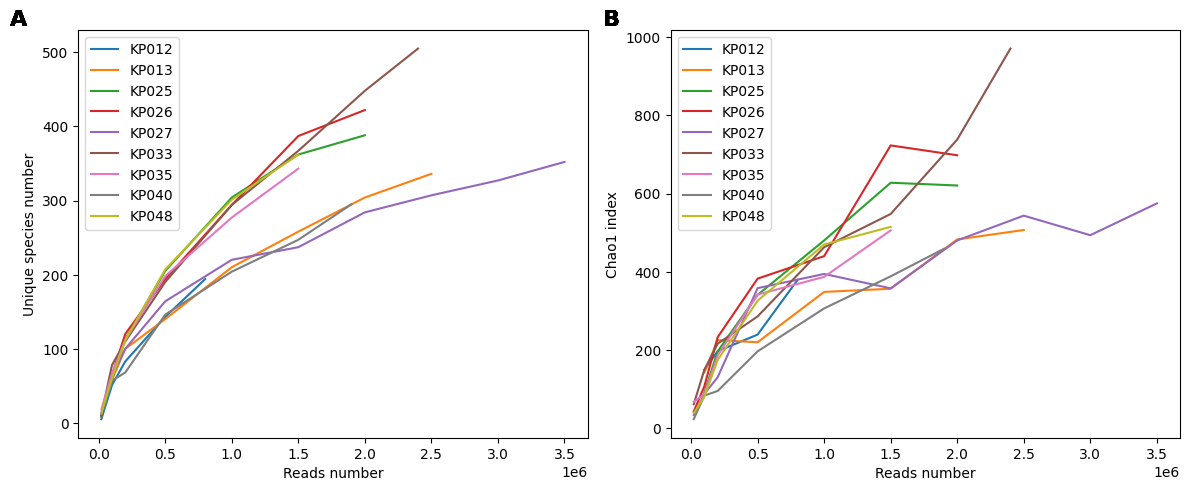

In [3]:
## 2 - less restrictive pruning
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, ind in enumerate(inds):
    reads_n = all_ns[i]
    species_num = []
    chao_all = []
    
    for n, samp in enumerate(reads_n):
        
        path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-"+str(ind+1)+"/blastn_nt_500/" + all_samps[ind] +"_"+ str(reads_n[n])+"_blastn_report.txt"
        df = process_data.read_n_clean_blastn(path_blast, top_hits = True, drop_sp = True, evalue = 1e-40, pident=0.95)
        species_num.append(len(set(df["species"])))
        chao_l = process_data.chao_idx(df["species"])
        chao_all.append(chao_l[0])


    axes[0].plot(np.multiply(reads_n,2), species_num, label=all_samps[ind])
    axes[0].legend()

    axes[1].plot(np.multiply(reads_n,2), chao_all, label=all_samps[ind])
    axes[1].legend()

    axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
    axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
    plt.tight_layout()

axes[0].set(xlabel="Reads number", ylabel="Unique species number")
axes[1].set(xlabel="Reads number", ylabel="Chao1 index")
plt.show()


fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/saturation_curve_randomized_single_lessres.png", dpi=300, bbox_inches='tight')


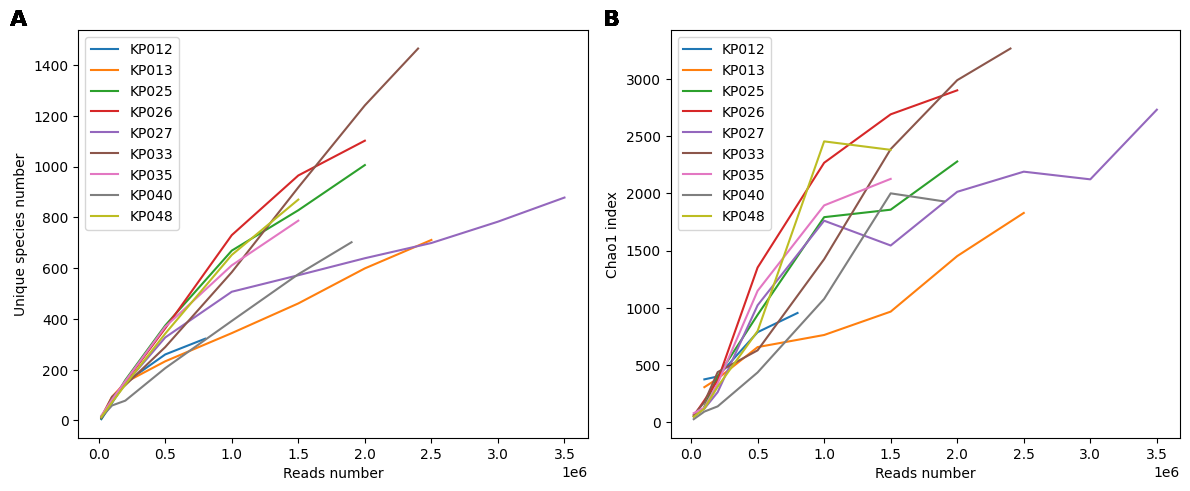

In [4]:
## 3 - no filtering
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, ind in enumerate(inds):
    reads_n = all_ns[i]
    species_num = []
    chao_all = []
    
    for n, samp in enumerate(reads_n):
        
        path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-"+str(ind+1)+"/blastn_nt_500/" + all_samps[ind] +"_"+ str(reads_n[n])+"_blastn_report.txt"
        df = process_data.read_n_clean_blastn(path_blast, top_hits = True, drop_sp = True, evalue = 1, pident=0)
        species_num.append(len(set(df["species"])))
        chao_l = process_data.chao_idx(df["species"])
        chao_all.append(chao_l[0])


    axes[0].plot(np.multiply(reads_n,2), species_num, label=all_samps[ind])
    axes[0].legend()

    axes[1].plot(np.multiply(reads_n,2), chao_all, label=all_samps[ind])
    axes[1].legend()

    axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
    axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes,
             fontsize=16, fontweight='bold', va='top', ha='right')
    plt.tight_layout()

axes[0].set(xlabel="Reads number", ylabel="Unique species number")
axes[1].set(xlabel="Reads number", ylabel="Chao1 index")
plt.show()


fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/figs/saturation_curve_randomized_single_nofilter.png", dpi=300, bbox_inches='tight')


Text(0.5, 0, 'Reads number')

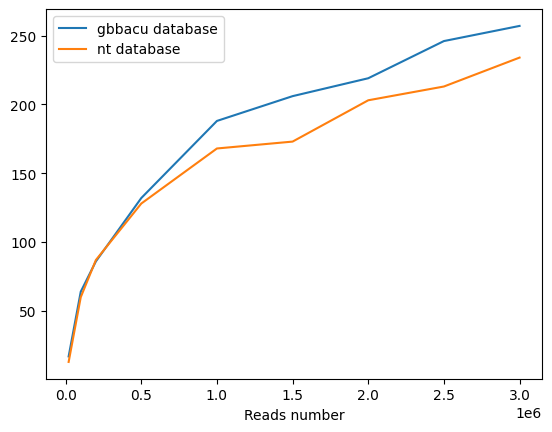

In [5]:
## 1
species_num = []
chao_all = []
ids = 7
reads_n = [10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1250000, 1500000] # , 500000, 750000, 1000000,  1250000, 1500000all_reads

for idx, samp in enumerate(reads_n):  
    path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-"+str(ids+1)+"/blastn_500/" + all_samps[ids] +"_"+ str(reads_n[idx])+"_blastn_report.txt"
    df = process_data.read_n_clean_blastn(path_blast, top_hits = True, drop_sp = True, evalue = 1e-100, pident=0.95)
    species_num.append(len(set(df["species"])))
    chao_l = process_data.chao_idx(df["species"])
    chao_all.append(chao_l[0])

plt.plot(np.multiply(reads_n, 2), species_num, label = "gbbacu database")

## 2
species_num = []
chao_all = []
ids = 7
reads_n = [10000, 50000, 100000, 250000, 500000, 750000, 1000000, 1250000, 1500000] # , 500000, 750000, 1000000,  1250000, 1500000all_reads
for idx, samp in enumerate(reads_n):  
    path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes/016-Meta-"+str(ids+1)+"/blastn_nt_500/" + all_samps[ids] +"_"+ str(reads_n[idx])+"_blastn_report.txt"
    df = process_data.read_n_clean_blastn(path_blast, top_hits = True, drop_sp = True, evalue = 1e-100, pident=0.95)
    species_num.append(len(set(df["species"])))
    chao_l = process_data.chao_idx(df["species"])
    chao_all.append(chao_l[0])

plt.plot(np.multiply(reads_n,2), species_num, label = "nt database")

plt.legend()
plt.xlabel("Reads number")